<a href="https://colab.research.google.com/github/Tjstell/mnist-multi-layer-perceptron-optimization/blob/main/MNIST_Multi_Layer_Perceptron_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MNIST Multi-Layer Perceptron Optimization**

**Project Overview**

This project systematically explores the hyperparameter space for Multi-Layer Perceptrons (MLPs) on the MNIST handwritten digit classification task. The goal was to identify the optimal combination of network architecture, activation functions, learning rates, and optimizers to maximize validation accuracy while staying within a 200,000 parameter constraint.

<br>

**Objective**

Train and evaluate MLP models on MNIST to:

- Achieve the highest possible validation accuracy under 200,000 parameters
- Understand the relative impact of different hyperparameters on model performance
- Document experimental methodology and results for reproducibility

<br>

**Constraints**

- No convolutional layers - MLPs only (fully connected/dense layers)
- Maximum 200,000 parameters per model
- No meta-learning techniques
- Standard MNIST dataset (60,000 training images, 10,000 test images)

<br>

**Experimental Design**

Initial Comprehensive Search (135 Experiments)

I designed a systematic grid search across four key dimensions:

<br>

1. Architectures (5 variations):

- Small [128, 64] - Baseline funnel architecture (~109k params)
- Medium [200, 100] - Wider layers for increased capacity (~178k params)
- Deep [128, 128, 64] - Three-layer depth test (~126k params)
- Narrow_Deep [64, 64, 64, 64] - Four layers testing efficiency through depth (~63k params)
- Very_Deep [150, 100, 75, 50, 25] - Five-layer hierarchical learning (~146k params)

<br>

2. Activation Functions (3 types):
- ReLU (Rectified Linear Unit)
- Tanh (Hyperbolic Tangent)
- Sigmoid

<br>

3. Learning Rates (3 values):
- 0.001 (conservative)
- 0.01 (moderate)
- 0.1 (aggressive)

<br>

4. Optimizers (3 algorithms):
- SGD (Stochastic Gradient Descent)
- SGD with Momentum (0.9)
- Adam (Adaptive Moment Estimation)

<br>

Total: 5 architectures × 3 activations × 3 learning rates × 3 optimizers = 135 unique configurations

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import numpy as np
import pandas as pd
from google.colab import files

# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images: 28x28 -> 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to categorical (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


Here I will iterate through multiple activation functions, learning rates, and optimizer configurations to find the highest validation accuracy.

In [ ]:
activation_functions = ['relu', 'tanh', 'sigmoid']

learning_rates = [0.001, 0.01, 0.1]

optimizer_configs = [
    {'name': 'SGD', 'optimizer': lambda lr: optimizers.SGD(learning_rate=lr)},
    {'name': 'SGD_Momentum', 'optimizer': lambda lr: optimizers.SGD(learning_rate=lr, momentum=0.9)},
    {'name': 'Adam', 'optimizer': lambda lr: optimizers.Adam(learning_rate=lr)}
]

# Architecture Format: list of layer sizes (number of neurons per hidden layer)
architectures = [
    {'name': 'Small', 'layers': [128, 64]},
          # Layer 1: (784 inputs × 128 neurons) + 128 biases = 100,480
          # Layer 2: (128 neurons × 64 neurons) + 64 biases = 8,256
          # Output: (64 neurons × 10 outputs) + 10 biases = 650
          # Total: ~109,386 parameters etc...
    {'name': 'Medium', 'layers': [200, 100]},    # ~178k parameters
    {'name': 'Deep', 'layers': [128, 128, 64]},  # ~126k parameters
    {'name': 'Narrow_Deep', 'layers': [64, 64, 64, 64]},  # ~63k parameters
    {'name': 'Very_Deep', 'layers': [150, 100, 75, 50, 25]}, # ~146k parameters
]

This is a quick test with a single model to make sure everything is working before I run the rest of the models.

In [ ]:
def build_model(layer_sizes, activation='relu'):
    """
    Build an MLP with specified architecture.

    layer_sizes: list of integers (neurons in each hidden layer)
    activation: activation function for hidden layers
    """
    model = models.Sequential()

    # Input layer
    model.add(layers.Dense(layer_sizes[0], activation=activation, input_shape=(784,)))

    # Hidden layers
    for neurons in layer_sizes[1:]:
        model.add(layers.Dense(neurons, activation=activation))

    # Output layer (10 classes, softmax for probability distribution)
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Test it - check parameter count
test_model = build_model([128, 64], 'relu')
print(f"Total parameters: {test_model.count_params():,}")
test_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Total parameters: 109,386


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Looks good!  I have Google Colab running on L4 GPU, which should speed up this process. Let's see what happens.

In [ ]:
# Storage for results
results = []

# Training settings
epochs = 10  # Adjust based on how long training takes
batch_size = 128

# Loop through all combinations
for arch in architectures:
    for activation in activation_functions:
        for lr in learning_rates:
            for opt_config in optimizer_configs:

                # Build model
                model = build_model(arch['layers'], activation)

                # Compile with specified optimizer
                optimizer = opt_config['optimizer'](lr)
                model.compile(
                    optimizer=optimizer,
                    loss='categorical_crossentropy',
                    metrics=['accuracy']
                )

                # Train
                print(f"\nTraining: {arch['name']} | {activation} | LR={lr} | {opt_config['name']}")

                history = model.fit(
                    x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=0  # Set to 1 if you want to see progress bars
                )

                # Get final epoch metrics
                train_acc = history.history['accuracy'][-1]
                val_acc = history.history['val_accuracy'][-1]
                train_loss = history.history['loss'][-1]
                val_loss = history.history['val_loss'][-1]

                # Store results
                results.append({
                    'Architecture': arch['name'],
                    'Layers': str(arch['layers']),
                    'Activation': activation,
                    'Learning_Rate': lr,
                    'Optimizer': opt_config['name'],
                    'Train_Acc': train_acc,
                    'Val_Acc': val_acc,
                    'Train_Loss': train_loss,
                    'Val_Loss': val_loss,
                    'Num_Parameters': model.count_params()
                })

                print(f"  → Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

                # Clear model from memory
                del model
                keras.backend.clear_session()

print("\nAll experiments complete!")


Training: Small | relu | LR=0.001 | SGD
  → Val Acc: 0.8492 | Val Loss: 0.6242

Training: Small | relu | LR=0.001 | SGD_Momentum
  → Val Acc: 0.9303 | Val Loss: 0.2371

Training: Small | relu | LR=0.001 | Adam
  → Val Acc: 0.9804 | Val Loss: 0.0741

Training: Small | relu | LR=0.01 | SGD
  → Val Acc: 0.9357 | Val Loss: 0.2261

Training: Small | relu | LR=0.01 | SGD_Momentum
  → Val Acc: 0.9753 | Val Loss: 0.0798

Training: Small | relu | LR=0.01 | Adam
  → Val Acc: 0.9655 | Val Loss: 0.1833

Training: Small | relu | LR=0.1 | SGD
  → Val Acc: 0.9750 | Val Loss: 0.0833

Training: Small | relu | LR=0.1 | SGD_Momentum
  → Val Acc: 0.9780 | Val Loss: 0.0851

Training: Small | relu | LR=0.1 | Adam
  → Val Acc: 0.5778 | Val Loss: 1.0537

Training: Small | tanh | LR=0.001 | SGD
  → Val Acc: 0.8610 | Val Loss: 0.5966

Training: Small | tanh | LR=0.001 | SGD_Momentum
  → Val Acc: 0.9257 | Val Loss: 0.2631

Training: Small | tanh | LR=0.001 | Adam
  → Val Acc: 0.9755 | Val Loss: 0.0781

Training

This will create and export an excel spreadsheet.

In [ ]:
# Convert to DataFrame
df_results = pd.DataFrame(results)

# Sort by validation accuracy (best first)
df_results = df_results.sort_values('Val_Acc', ascending=False)

# Display in Colab
print("\n" + "="*80)
print("EXPERIMENT RESULTS")
print("="*80)
print(df_results.to_string(index=False))

# Save to Excel
filename = 'TaylorStell_mnist_mlp_experiments.xlsx'
df_results.to_excel(filename, index=False)

# Download the file
files.download(filename)

print(f"\n✓ Results saved to {filename}")


EXPERIMENT RESULTS
Architecture                 Layers Activation  Learning_Rate    Optimizer  Train_Acc  Val_Acc  Train_Loss  Val_Loss  Num_Parameters
       Small              [128, 64]       relu          0.001         Adam   0.993350   0.9804    0.022934  0.074053          109386
      Medium             [200, 100]       tanh          0.100 SGD_Momentum   0.998350   0.9797    0.007230  0.073320          178110
       Small              [128, 64]       relu          0.100 SGD_Momentum   0.992317   0.9780    0.022855  0.085097          109386
        Deep         [128, 128, 64]       relu          0.001         Adam   0.993383   0.9780    0.019370  0.081756          125898
   Very_Deep [150, 100, 75, 50, 25]       relu          0.100 SGD_Momentum   0.987100   0.9777    0.043951  0.093885          145760
      Medium             [200, 100]       tanh          0.001         Adam   0.995750   0.9769    0.016061  0.078448          178110
        Deep         [128, 128, 64]       relu   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Results saved to TaylorStell_mnist_mlp_experiments.xlsx


Here is a quick analysis of the results

In [ ]:
# Show best configuration
best = df_results.iloc[0]
print("\n" + "="*80)
print("BEST CONFIGURATION")
print("="*80)
print(f"Architecture: {best['Architecture']} {best['Layers']}")
print(f"Activation: {best['Activation']}")
print(f"Learning Rate: {best['Learning_Rate']}")
print(f"Optimizer: {best['Optimizer']}")
print(f"Validation Accuracy: {best['Val_Acc']:.4f}")
print(f"Validation Loss: {best['Val_Loss']:.4f}")

# Summary statistics by activation function
print("\n" + "="*80)
print("AVERAGE VALIDATION ACCURACY BY ACTIVATION FUNCTION")
print("="*80)
print(df_results.groupby('Activation')['Val_Acc'].mean().sort_values(ascending=False))

# Summary by optimizer
print("\n" + "="*80)
print("AVERAGE VALIDATION ACCURACY BY OPTIMIZER")
print("="*80)
print(df_results.groupby('Optimizer')['Val_Acc'].mean().sort_values(ascending=False))


BEST CONFIGURATION
Architecture: Small [128, 64]
Activation: relu
Learning Rate: 0.001
Optimizer: Adam
Validation Accuracy: 0.9804
Validation Loss: 0.0741

AVERAGE VALIDATION ACCURACY BY ACTIVATION FUNCTION
Activation
relu       0.882927
tanh       0.865216
sigmoid    0.629769
Name: Val_Acc, dtype: float64

AVERAGE VALIDATION ACCURACY BY OPTIMIZER
Optimizer
SGD_Momentum    0.874136
SGD             0.761022
Adam            0.742753
Name: Val_Acc, dtype: float64


Some visualizations to better understand results.


VISUALIZATION 1: Architecture Performance


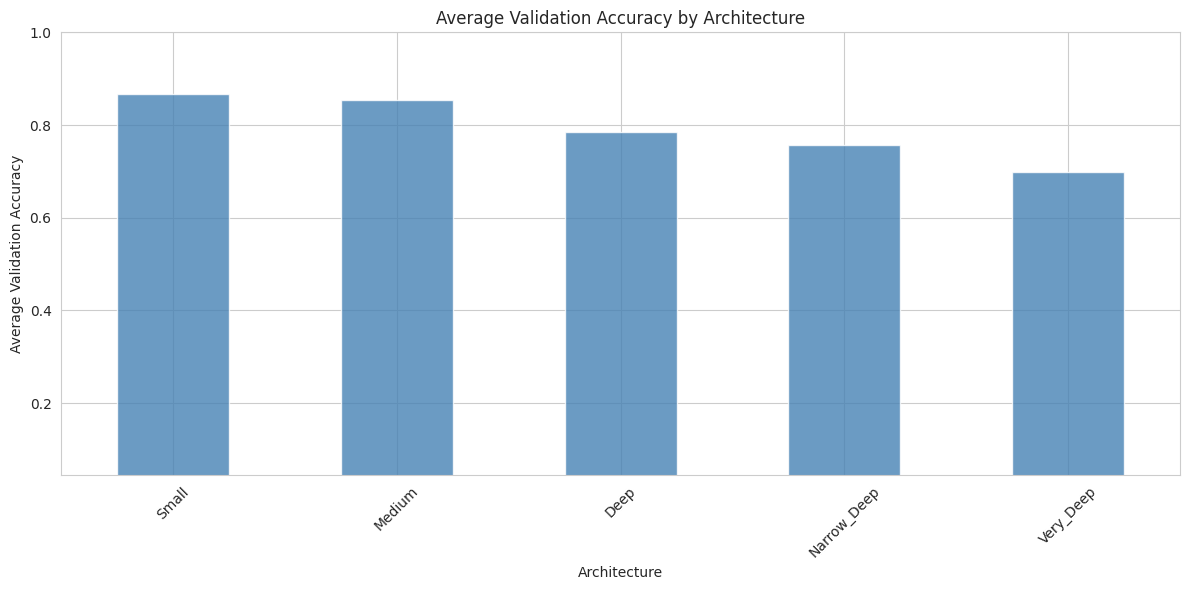

                  mean     max     min
Architecture                          
Small         0.866230  0.9804  0.1910
Medium        0.854407  0.9797  0.2034
Deep          0.785756  0.9780  0.1010
Narrow_Deep   0.757526  0.9753  0.0958
Very_Deep     0.699267  0.9777  0.1009

VISUALIZATION 2: Activation Function Performance


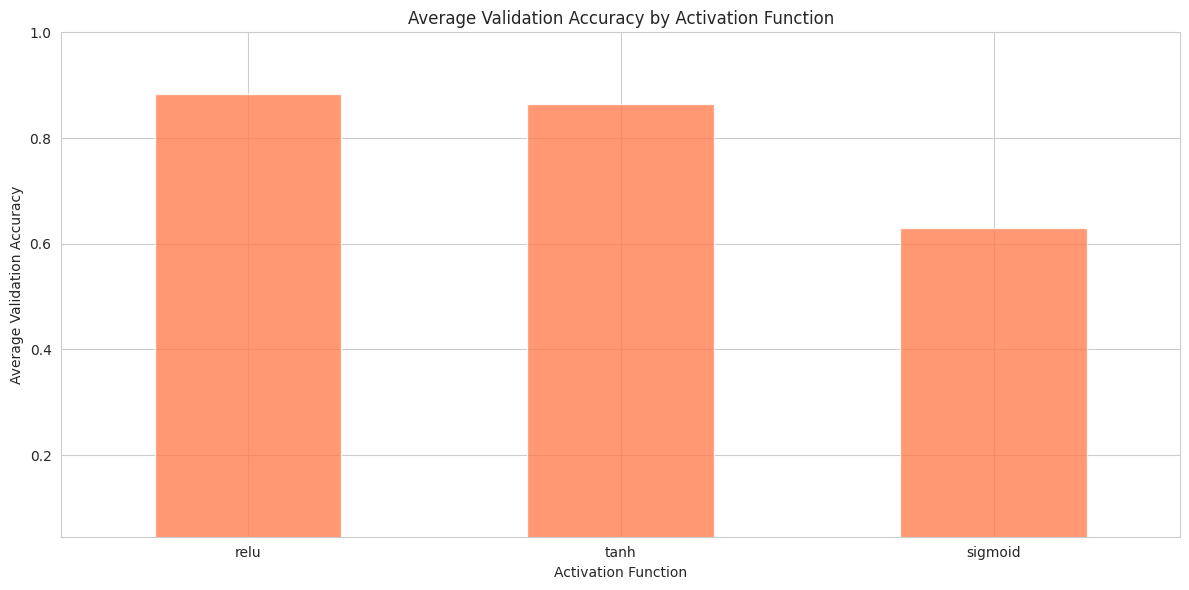

                mean     max     min
Activation                          
relu        0.882927  0.9804  0.1009
tanh        0.865216  0.9797  0.0958
sigmoid     0.629769  0.9749  0.1010

VISUALIZATION 3: Optimizer Performance


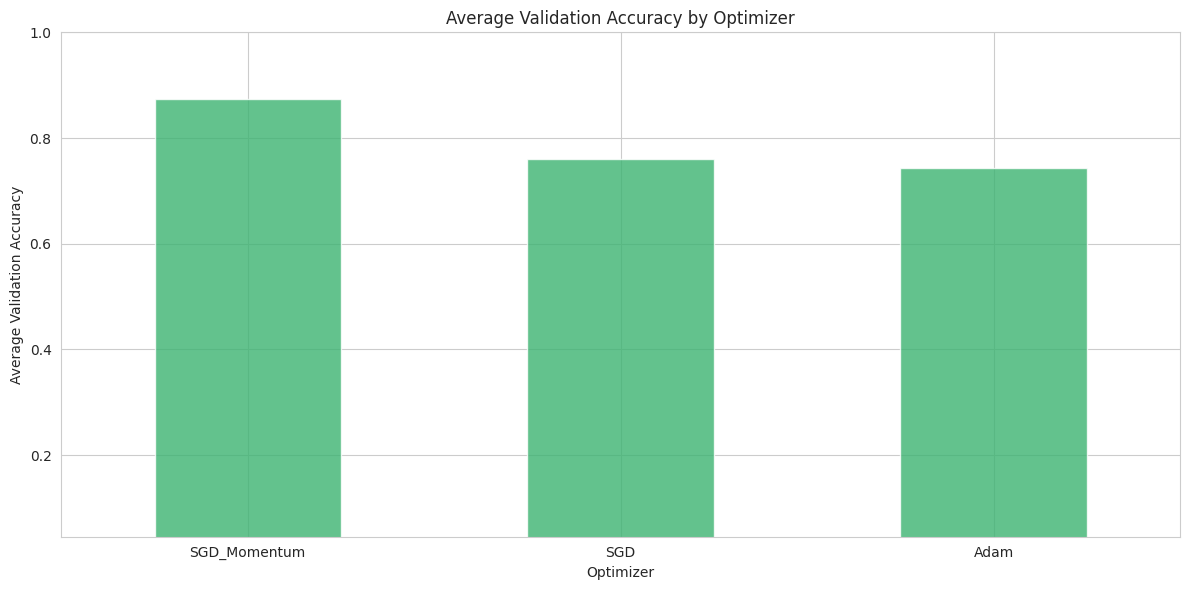

                  mean     max     min
Optimizer                             
SGD_Momentum  0.874136  0.9797  0.1135
SGD           0.761022  0.9769  0.1135
Adam          0.742753  0.9804  0.0958

VISUALIZATION 4: Learning Rate Performance


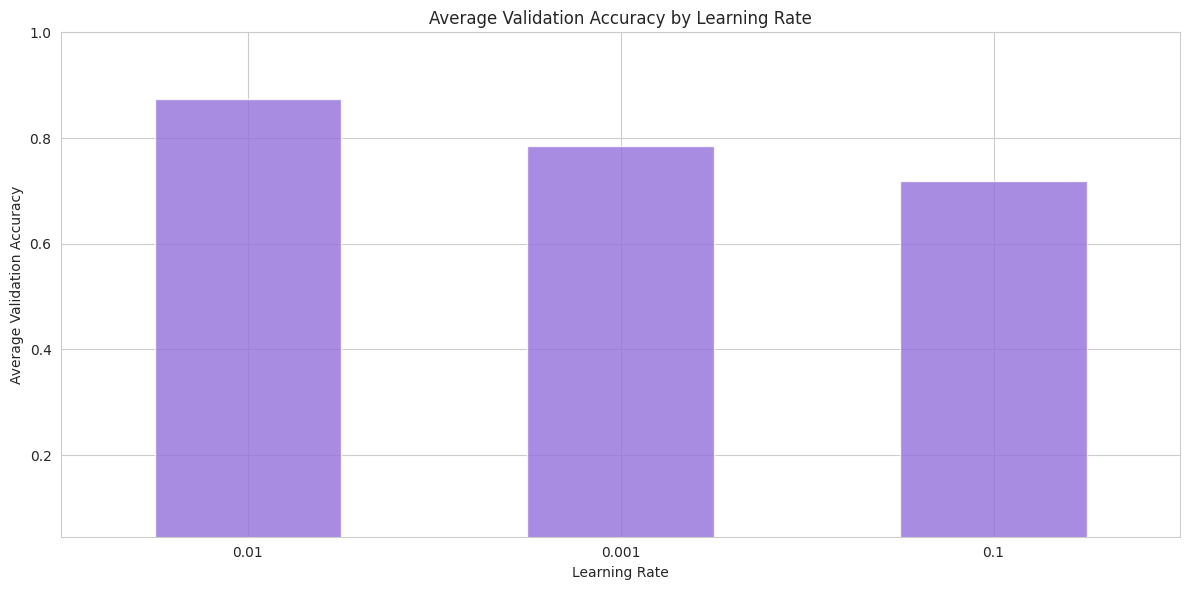

                   mean     max     min
Learning_Rate                          
0.010          0.873678  0.9758  0.1135
0.001          0.785593  0.9804  0.1135
0.100          0.718640  0.9797  0.0958

VISUALIZATION 5: Activation Function × Optimizer Heatmap


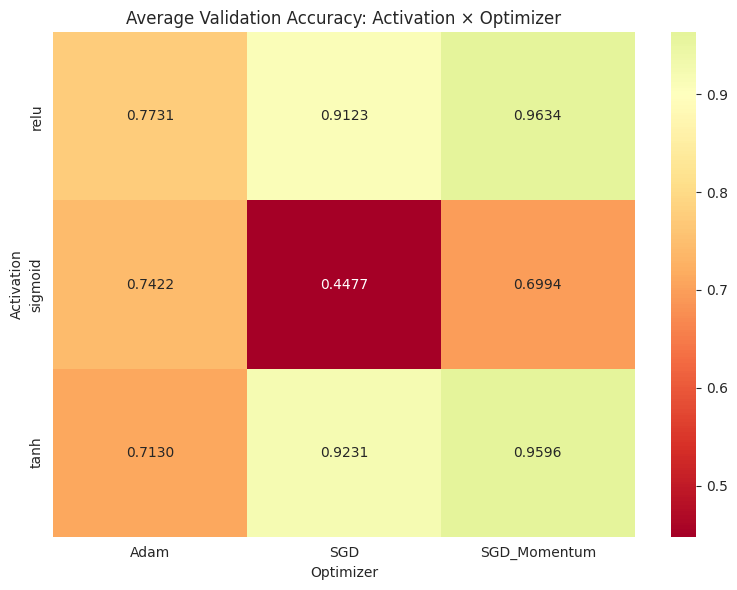


VISUALIZATION 6: Architecture × Learning Rate Heatmap


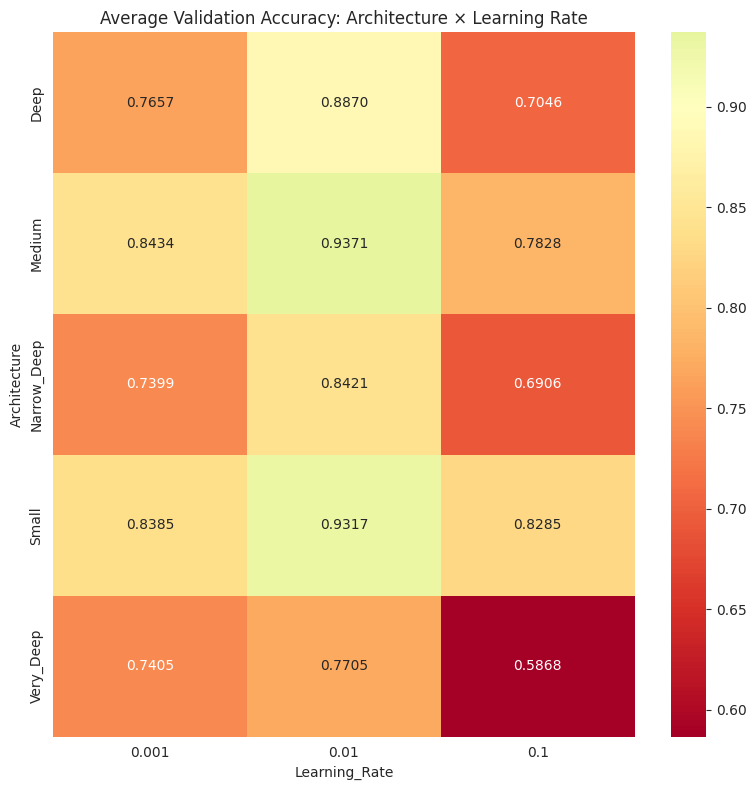


VISUALIZATION 7: Does More Parameters = Better Performance?


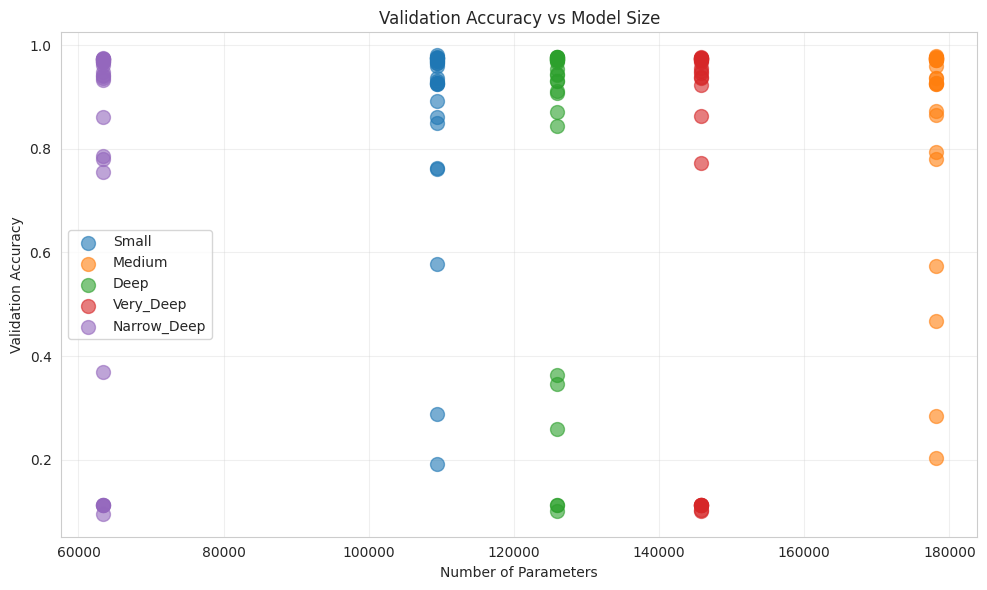


VISUALIZATION 8: Top 10 Configurations


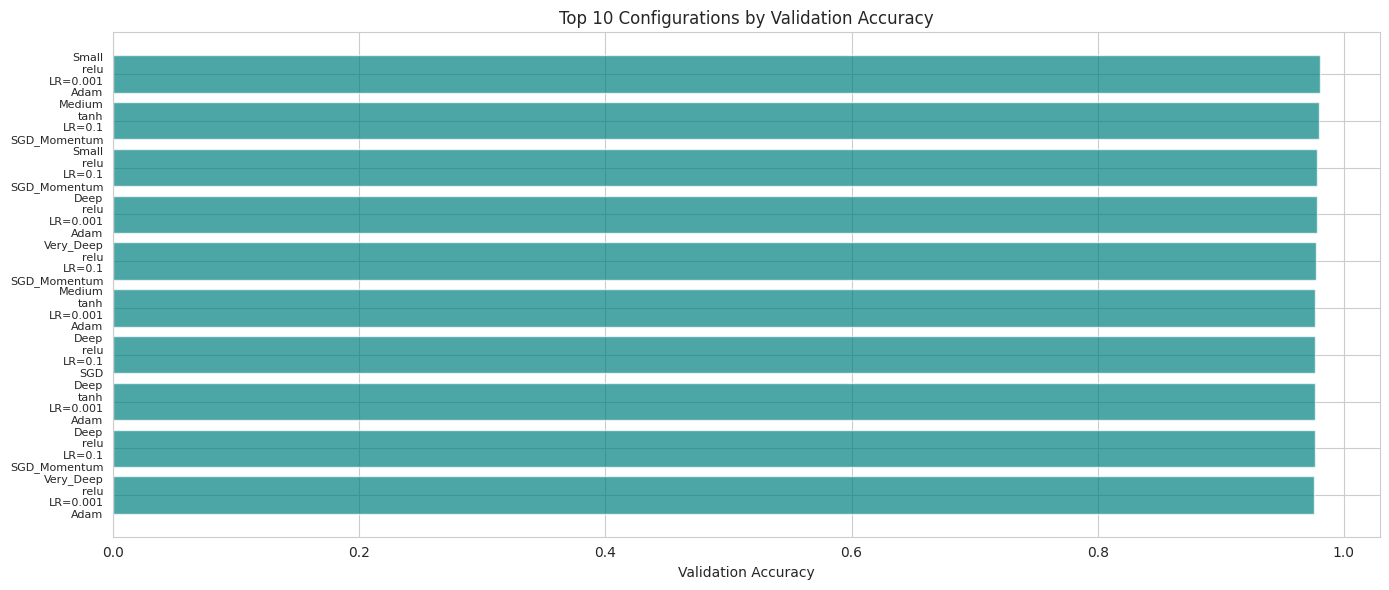

    Architecture Activation  Learning_Rate     Optimizer  Val_Acc
2          Small       relu          0.001          Adam   0.9804
43        Medium       tanh          0.100  SGD_Momentum   0.9797
7          Small       relu          0.100  SGD_Momentum   0.9780
56          Deep       relu          0.001          Adam   0.9780
115    Very_Deep       relu          0.100  SGD_Momentum   0.9777
38        Medium       tanh          0.001          Adam   0.9769
60          Deep       relu          0.100           SGD   0.9769
65          Deep       tanh          0.001          Adam   0.9768
61          Deep       relu          0.100  SGD_Momentum   0.9766
110    Very_Deep       relu          0.001          Adam   0.9759


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Compare Architectures - Average Performance
print("\n" + "="*80)
print("VISUALIZATION 1: Architecture Performance")
print("="*80)

arch_performance = df_results.groupby('Architecture')['Val_Acc'].agg(['mean', 'max', 'min'])
arch_performance = arch_performance.sort_values('mean', ascending=False)

fig, ax = plt.subplots()
arch_performance['mean'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Architecture')
ax.set_ylabel('Average Validation Accuracy')
ax.set_title('Average Validation Accuracy by Architecture')
ax.set_ylim([arch_performance['min'].min() - 0.05, 1.0])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(arch_performance)


# 2. Compare Activation Functions
print("\n" + "="*80)
print("VISUALIZATION 2: Activation Function Performance")
print("="*80)

activation_performance = df_results.groupby('Activation')['Val_Acc'].agg(['mean', 'max', 'min'])
activation_performance = activation_performance.sort_values('mean', ascending=False)

fig, ax = plt.subplots()
activation_performance['mean'].plot(kind='bar', ax=ax, color='coral', alpha=0.8)
ax.set_xlabel('Activation Function')
ax.set_ylabel('Average Validation Accuracy')
ax.set_title('Average Validation Accuracy by Activation Function')
ax.set_ylim([activation_performance['min'].min() - 0.05, 1.0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(activation_performance)


# 3. Compare Optimizers
print("\n" + "="*80)
print("VISUALIZATION 3: Optimizer Performance")
print("="*80)

optimizer_performance = df_results.groupby('Optimizer')['Val_Acc'].agg(['mean', 'max', 'min'])
optimizer_performance = optimizer_performance.sort_values('mean', ascending=False)

fig, ax = plt.subplots()
optimizer_performance['mean'].plot(kind='bar', ax=ax, color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Optimizer')
ax.set_ylabel('Average Validation Accuracy')
ax.set_title('Average Validation Accuracy by Optimizer')
ax.set_ylim([optimizer_performance['min'].min() - 0.05, 1.0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(optimizer_performance)


# 4. Compare Learning Rates
print("\n" + "="*80)
print("VISUALIZATION 4: Learning Rate Performance")
print("="*80)

lr_performance = df_results.groupby('Learning_Rate')['Val_Acc'].agg(['mean', 'max', 'min'])
lr_performance = lr_performance.sort_values('mean', ascending=False)

fig, ax = plt.subplots()
lr_performance['mean'].plot(kind='bar', ax=ax, color='mediumpurple', alpha=0.8)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Average Validation Accuracy')
ax.set_title('Average Validation Accuracy by Learning Rate')
ax.set_ylim([lr_performance['min'].min() - 0.05, 1.0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(lr_performance)


# 5. Heatmap: Activation vs Optimizer (which combinations work best?)
print("\n" + "="*80)
print("VISUALIZATION 5: Activation Function × Optimizer Heatmap")
print("="*80)

pivot_act_opt = df_results.pivot_table(
    values='Val_Acc',
    index='Activation',
    columns='Optimizer',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_act_opt, annot=True, fmt='.4f', cmap='RdYlGn', center=0.90)
plt.title('Average Validation Accuracy: Activation × Optimizer')
plt.tight_layout()
plt.show()


# 6. Heatmap: Architecture vs Learning Rate
print("\n" + "="*80)
print("VISUALIZATION 6: Architecture × Learning Rate Heatmap")
print("="*80)

pivot_arch_lr = df_results.pivot_table(
    values='Val_Acc',
    index='Architecture',
    columns='Learning_Rate',
    aggfunc='mean'
)

plt.figure(figsize=(8, 8))
sns.heatmap(pivot_arch_lr, annot=True, fmt='.4f', cmap='RdYlGn', center=0.90)
plt.title('Average Validation Accuracy: Architecture × Learning Rate')
plt.tight_layout()
plt.show()


# 7. Scatter Plot: Parameters vs Performance
print("\n" + "="*80)
print("VISUALIZATION 7: Does More Parameters = Better Performance?")
print("="*80)

plt.figure(figsize=(10, 6))
for arch in df_results['Architecture'].unique():
    subset = df_results[df_results['Architecture'] == arch]
    plt.scatter(subset['Num_Parameters'], subset['Val_Acc'],
                label=arch, alpha=0.6, s=100)

plt.xlabel('Number of Parameters')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Model Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 8. Top 10 Configurations (visual bar chart)
print("\n" + "="*80)
print("VISUALIZATION 8: Top 10 Configurations")
print("="*80)

top_10 = df_results.head(10).copy()
top_10['Config'] = (top_10['Architecture'] + '\n' +
                    top_10['Activation'] + '\n' +
                    'LR=' + top_10['Learning_Rate'].astype(str) + '\n' +
                    top_10['Optimizer'])

plt.figure(figsize=(14, 6))
plt.barh(range(len(top_10)), top_10['Val_Acc'], color='teal', alpha=0.7)
plt.yticks(range(len(top_10)), top_10['Config'], fontsize=8)
plt.xlabel('Validation Accuracy')
plt.title('Top 10 Configurations by Validation Accuracy')
plt.gca().invert_yaxis()  # Best on top
plt.tight_layout()
plt.show()

print(top_10[['Architecture', 'Activation', 'Learning_Rate', 'Optimizer', 'Val_Acc']])

Some of these results were expected.  I knew that relu would be the best performing activation function, however I was surprised that tanh had 3 of the top 10 results.

For the architecture it was interesting how the results decreased as the size and complexity of the models increased, with the very deep model with the lowest average.

The optimizer I found interesting, as SGD Momentum had the highest average accuracy, but ADAM was able to generate the highest single accuracy results.

The learning rate was similarly interesting, with 0.001 achieving the maximum accuracy, yet 0.010 scoring the highest average.

As a side note, I was curious to see how the Narrow Deep models would fare, as they had by far the lowest number of parameters at only 63k.  Not surprisingly, the majority of those models scored in the lower half of the results, but considering the much lower cost, it was impressive that the max validation accuracy was 0.9753, which is not too far off the best model's score of 0.9804.

TLDR: The best model was Small Architecture, ReLu Activation Function, Learning Rate of 0.001, and ADAM as the Optimizer.

Validation Accuracy: 0.9804

Training Accuracy: 0.99335

Validation Loss: 0.0741

Training Loss: 0.022934

My initial best model showed signs of overfitting with training accuracy exceeding validation accuracy by 1.3%. To improve generalization, I applied dropout regularization. I tested multiple dropout rates to find the optimal balance between model capacity and regularization.

In [ ]:
def build_model_with_dropout(layer_sizes, activation='relu', dropout_rate=0.2):
    model = models.Sequential()
    model.add(layers.Dense(layer_sizes[0], activation=activation, input_shape=(784,)))
    model.add(layers.Dropout(dropout_rate))

    for neurons in layer_sizes[1:]:
        model.add(layers.Dense(neurons, activation=activation))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))
    return model

activation = 'relu'
arch = {'name': 'Small', 'layers': [128, 64]}
lr = 0.001
epochs = 10  # I tried re-running this with 15 epochs but got worse results

dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4]  # Include 0.0 as baseline to compare

results_dropout = []

for dropout in dropout_rates:
    model = build_model_with_dropout(arch['layers'], activation, dropout)

    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining: [128, 64] + relu + LR=0.001 + Adam + Dropout={dropout}")

    history = model.fit(
        x_train, y_train,
        batch_size=128,
        epochs=epochs,
        validation_data=(x_test, y_test),
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    results_dropout.append({
        'Dropout': dropout,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Train_Loss': train_loss,
        'Val_Loss': val_loss,
        'Gap': train_acc - val_acc
    })

    print(f"  → Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {(train_acc - val_acc):.4f}")

    del model
    keras.backend.clear_session()

df_dropout = pd.DataFrame(results_dropout)
df_dropout = df_dropout.sort_values('Val_Acc', ascending=False)

print("\n" + "="*80)
print("DROPOUT RESULTS (10 EPOCHS)")
print("="*80)
print(df_dropout)
print(f"\nBest Val Acc: {df_dropout.iloc[0]['Val_Acc']:.4f} with Dropout={df_dropout.iloc[0]['Dropout']}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: [128, 64] + relu + LR=0.001 + Adam + Dropout=0.0
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8240 - loss: 0.6203 - val_accuracy: 0.9515 - val_loss: 0.1597
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9568 - loss: 0.1470 - val_accuracy: 0.9665 - val_loss: 0.1124
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.0961 - val_accuracy: 0.9693 - val_loss: 0.0985
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0709 - val_accuracy: 0.9732 - val_loss: 0.0871
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0562 - val_accuracy: 0.9760 - val_loss: 0.0756
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9876 - loss: 0.0415 - val_accuracy: 0.9757 - val_loss: 0.0790
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0360 - val_accuracy: 0.9730 - val_loss: 0.0955
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2

While adding dropout did decrease the training accuracy and shrink the gap between this and the validation accuracy, it failed to achieve a higher validation score.  This leads me to believe that a small amount of overfitting is necessary, at least for these models that I created, to achieve the highest validation accuracy that I can.  I will have to accept that the highest validation accuracy I can achieve from these experiments is 0.9804.